# **Практическая работа. Геомаркетинговое исследование территорий с применением методов машинного обучения**


## **Цель работы**


Овладеть методами пространственного анализа и машинного обучения для решения практической задачи определения оптимальных локаций размещения коммерческих объектов.

## **Введение**


В современном бизнесе местоположение коммерческого объекта играет ключевую роль в его успешности. Геомаркетинговый анализ позволяет объективно оценить привлекательность различных локаций, опираясь на количественные показатели и алгоритмы машинного обучения.

В рамках данной работы вы примените полный цикл пространственного анализа, включая сбор данных из открытых источников, обработку и агрегацию пространственной информации, обучение моделей машинного обучения и визуализацию результатов.

## **Задание**


Провести геомаркетинговое исследование для выбора оптимальных локаций размещения новых точек определенного типа бизнеса на территории выбранного города.

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и определение задачи**



1. **Индивидуальный выбор территории и типа бизнеса**:
   - Выберите город/район для проведения анализа (например, центральная часть Москвы, Санкт-Петербурга или любого другого крупного города)
   - Определите тип бизнеса для анализа (аптеки, продуктовые магазины, пункты выдачи заказов, рестораны определенной кухни и т.д.)
   - Обоснуйте свой выбор: почему данная территория и тип бизнеса интересны для анализа?

2. **Определение ключевых факторов успешности**:
   - Самостоятельно сформулируйте не менее 5 факторов, которые могут влиять на успешность выбранного типа бизнеса
   - Для каждого фактора определите, какими данными из OpenStreetMap его можно количественно описать
   - Составьте таблицу соответствия между факторами и тегами OpenStreetMap

3. **Сбор исходных данных**:
   - Настройте необходимые библиотеки из теоретического материала
   - Определите необходимую область интереса (ROI) с помощью интерактивной карты
   - Загрузите данные о существующих объектах вашего типа бизнеса и объектах инфраструктуры, связанных с выделенными вами факторами

Территория: Москва
Тип бизнеса: Wildberries
Обоснование: ПВЗ подходят для геомаркетингового анализа, потому что для них важны транспортная доступность,
образовательные и зелёные зоны, а также наличие других точек притяжения и конкурентов.


,Фактор,Тег OSM
0,Образовательная инфраструктура,amenity=school
1,Транспортная доступность,railway=subway_entrance
2,Велоинфраструктура,highway=cycleway
3,Зелёные зоны,leisure=park
4,Точки притяжения,amenity=restaurant
5,Конкуренция,name=Wildberries


Загрузка schools...
Загрузка subways...
Загрузка bike_paths...
Загрузка parks...
Загрузка restaurants...
Загрузка wb...

Количество объектов:
schools 118
subways 156
bike_paths 87
parks 185
restaurants 974
wb 98


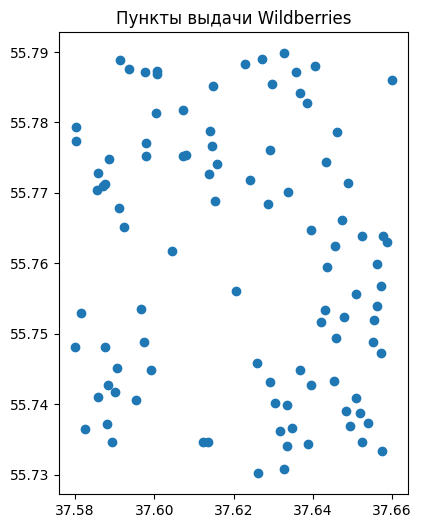

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import h3
import leafmap

from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Выберем центральную часть Москвы и пункты выдачи Wildberries.
# Территория небольшая, чтобы анализ выполнялся быстрее.
place = 'Москва'
business = 'Wildberries'
bbox = [37.58, 55.73, 37.66, 55.79]

print('Территория:', place)
print('Тип бизнеса:', business)
print('Обоснование: ПВЗ подходят для геомаркетингового анализа, потому что для них важны транспортная доступность,')
print('образовательные и зелёные зоны, а также наличие других точек притяжения и конкурентов.')

# Факторы успешности и теги OpenStreetMap.
factors = pd.DataFrame({
    'Фактор': [
        'Образовательная инфраструктура',
        'Транспортная доступность',
        'Велоинфраструктура',
        'Зелёные зоны',
        'Точки притяжения',
        'Конкуренция'
    ],
    'Тег OSM': [
        'amenity=school',
        'railway=subway_entrance',
        'highway=cycleway',
        'leisure=park',
        'amenity=restaurant',
        'name=Wildberries'
    ]
})

display(factors)

tags = {
    'schools': {'amenity': 'school'},
    'subways': {'railway': 'subway_entrance'},
    'bike_paths': {'highway': 'cycleway'},
    'parks': {'leisure': 'park'},
    'restaurants': {'amenity': 'restaurant'},
    'wb': {'name': 'Wildberries'}
}

west, south, east, north = bbox
data = {}

for key, tag in tags.items():
    print(f'Загрузка {key}...')
    try:
        data[key] = ox.features_from_bbox(
            (west, south, east, north),
            tags=tag
        )
    except Exception:
        data[key] = gpd.GeoDataFrame(
            columns=['geometry'],
            geometry='geometry',
            crs='EPSG:4326'
        )

# Переводим данные в систему координат с метрами.
for key in data:
    if not data[key].empty:
        data[key] = data[key].to_crs('EPSG:3857')

print('\nКоличество объектов:')
for key, value in data.items():
    print(key, len(value))

# Карта существующих ПВЗ.
if not data['wb'].empty:
    wb_viz = data['wb'].to_crs('EPSG:4326')
    wb_viz.plot(figsize=(8, 6))
    plt.title('Пункты выдачи Wildberries')
    plt.show()


### **Часть 2. Пространственное агрегирование и создание признаков**


1. **Создание гексагональной сетки**:
   - Самостоятельно определите оптимальную детализацию сетки H3 для вашего анализа
   - Обоснуйте выбор разрешения (resolution) сетки с учётом масштаба вашей территории и специфики бизнеса
   - Покройте территорию гексагональной сеткой выбранного разрешения

2. **Инженерия пространственных признаков**:
   - Определите радиусы для анализа ближнего и среднего окружения (могут отличаться от предложенных в теории в зависимости от специфики вашего бизнеса)
   - Разработайте и реализуйте не менее 10 пространственных признаков, описывающих характеристики каждой ячейки
   - **Дополнительное задание**: придумайте и реализуйте не менее 2 пространственных признаков, которых нет в теоретическом материале

3. **Анализ полученных признаков**:
   - Рассчитайте базовую статистику по каждому признаку
   - Исследуйте корреляции между признаками
   - Выявите и обработайте выбросы и пропущенные значения, если они имеются

In [2]:
# Создаём гексагональную сетку H3.
# Для небольшой территории используем resolution = 8.
resolution = 8

bbox_polygon = box(*bbox)

# Поддержка актуальной версии h3 и старого синтаксиса из примера теории.
if hasattr(h3, 'polygon_to_cells'):
    coords = list(bbox_polygon.exterior.coords)
    polygon_h3 = h3.LatLngPoly(
        [(lat, lon) for lon, lat in coords]
    )
    h3_indexes = list(
        h3.polygon_to_cells(
            polygon_h3,
            resolution
        )
    )
    h3_geometries = [
        Polygon(
            [(lon, lat) for lat, lon in h3.cell_to_boundary(h)]
        )
        for h in h3_indexes
    ]
else:
    h3_indexes = list(
        h3.polyfill_geojson(
            bbox_polygon.__geo_interface__,
            resolution
        )
    )
    h3_geometries = [
        Polygon(
            h3.h3_to_geo_boundary(
                h,
                geo_json=True
            )
        )
        for h in h3_indexes
    ]

h3_gdf = gpd.GeoDataFrame(
    {
        'h3_index': h3_indexes,
        'geometry': h3_geometries
    },
    crs='EPSG:4326'
).to_crs('EPSG:3857')

print('Разрешение H3:', resolution)
print('Количество ячеек:', len(h3_gdf))

# Радиусы из теоретического примера.
radius_near = 800
radius_middle = 1600

# Для ускорения используем пространственные соединения.
near_buffers = h3_gdf[['geometry']].copy()
near_buffers['geometry'] = near_buffers.geometry.buffer(radius_near)

middle_buffers = h3_gdf[['geometry']].copy()
middle_buffers['geometry'] = middle_buffers.geometry.buffer(radius_middle)

feature_columns = [
    'num_schools_near',
    'num_schools_middle',
    'num_subways_near',
    'num_subways_middle',
    'bike_length_near',
    'bike_length_middle',
    'park_area_near',
    'park_area_middle',
    'restaurant_near',
    'restaurant_middle',
    'wb_near',
    'wb_middle'
]

for col in feature_columns:
    h3_gdf[col] = 0.0

def add_count_feature(source, buffers, column):
    if source.empty:
        return
    joined = gpd.sjoin(
        source[['geometry']],
        buffers[['geometry']],
        how='inner',
        predicate='intersects'
    )
    if not joined.empty:
        counts = joined.groupby('index_right').size()
        h3_gdf.loc[counts.index, column] = counts

def add_sum_feature(source, buffers, column, measure='length'):
    if source.empty:
        return
    joined = gpd.sjoin(
        source[['geometry']],
        buffers[['geometry']],
        how='inner',
        predicate='intersects'
    )
    if not joined.empty:
        if measure == 'length':
            values = source.loc[joined.index].geometry.length
        else:
            values = source.loc[joined.index].geometry.area
        sums = values.groupby(joined['index_right']).sum()
        h3_gdf.loc[sums.index, column] = sums

# 10 основных пространственных признаков:
# 5 факторов в ближнем окружении и 5 в среднем окружении.
add_count_feature(data['schools'], near_buffers, 'num_schools_near')
add_count_feature(data['schools'], middle_buffers, 'num_schools_middle')

add_count_feature(data['subways'], near_buffers, 'num_subways_near')
add_count_feature(data['subways'], middle_buffers, 'num_subways_middle')

add_sum_feature(data['bike_paths'], near_buffers, 'bike_length_near', 'length')
add_sum_feature(data['bike_paths'], middle_buffers, 'bike_length_middle', 'length')

add_sum_feature(data['parks'], near_buffers, 'park_area_near', 'area')
add_sum_feature(data['parks'], middle_buffers, 'park_area_middle', 'area')

add_count_feature(data['restaurants'], near_buffers, 'restaurant_near')
add_count_feature(data['restaurants'], middle_buffers, 'restaurant_middle')

# 2 дополнительных признака, которых нет в теоретическом примере:
# количество существующих ПВЗ в радиусах 800 и 1600 м.
add_count_feature(data['wb'], near_buffers, 'wb_near')
add_count_feature(data['wb'], middle_buffers, 'wb_middle')

h3_gdf[feature_columns] = h3_gdf[feature_columns].fillna(0)

print('\nБазовая статистика:')
display(h3_gdf[feature_columns].describe())

print('\nКорреляция признаков:')
display(h3_gdf[feature_columns].corr().round(2))

print('\nПропуски:')
print(h3_gdf[feature_columns].isna().sum().sum())


Разрешение H3: 8
Количество ячеек: 51

Базовая статистика:


,num_schools_near,num_schools_middle,num_subways_near,num_subways_middle,bike_length_near,bike_length_middle,park_area_near,park_area_middle,restaurant_near,restaurant_middle,wb_near,wb_middle
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,5.100000e+01,5.100000e+01,51.000000,51.000000,51.000000,51.000000
mean,9.000000,17.647059,11.196078,23.529412,5464.634767,10337.897437,8.637656e+05,1.521452e+06,69.490196,145.313725,6.529412,13.215686
std,3.867816,4.782566,9.967988,16.630518,5249.851752,7229.312221,7.730519e+05,9.761744e+05,48.700050,90.666089,3.300624,4.670391
min,1.000000,7.000000,0.000000,4.000000,0.000000,0.000000,0.000000e+00,2.953058e+05,3.000000,13.000000,1.000000,4.000000
25%,7.000000,13.500000,5.000000,11.000000,928.048538,4537.634514,3.110285e+05,7.588422e+05,37.000000,72.000000,3.500000,10.500000
50%,8.000000,19.000000,7.000000,18.000000,3237.624013,9154.944436,6.630757e+05,1.308842e+06,56.000000,114.000000,7.000000,13.000000
75%,12.000000,21.000000,14.500000,34.000000,9012.046191,16247.142736,1.092438e+06,1.934295e+06,91.500000,204.500000,9.000000,16.000000
max,17.000000,26.000000,45.000000,63.000000,18909.746865,24352.447573,3.165370e+06,3.810022e+06,217.000000,367.000000,12.000000,24.000000



Корреляция признаков:


,num_schools_near,num_schools_middle,num_subways_near,num_subways_middle,bike_length_near,bike_length_middle,park_area_near,park_area_middle,restaurant_near,restaurant_middle,wb_near,wb_middle
num_schools_near,1.00,0.74,-0.13,0.01,0.45,0.32,0.04,0.08,0.28,0.28,0.36,0.40
num_schools_middle,0.74,1.00,0.20,0.34,0.54,0.60,0.15,0.28,0.50,0.57,0.22,0.38
num_subways_near,-0.13,0.20,1.00,0.82,0.33,0.51,-0.05,0.14,0.72,0.70,-0.33,-0.23
num_subways_middle,0.01,0.34,0.82,1.00,0.42,0.60,-0.05,0.22,0.72,0.77,-0.26,-0.13
bike_length_near,0.45,0.54,0.33,0.42,1.00,0.76,0.28,0.32,0.71,0.72,-0.36,-0.25
bike_length_middle,0.32,0.60,0.51,0.60,0.76,1.00,0.26,0.49,0.79,0.86,-0.34,-0.25
park_area_near,0.04,0.15,-0.05,-0.05,0.28,0.26,1.00,0.80,-0.06,0.01,-0.23,-0.19
park_area_middle,0.08,0.28,0.14,0.22,0.32,0.49,0.80,1.00,0.17,0.24,-0.17,-0.16
restaurant_near,0.28,0.50,0.72,0.72,0.71,0.79,-0.06,0.17,1.00,0.96,-0.23,-0.14
restaurant_middle,0.28,0.57,0.70,0.77,0.72,0.86,0.01,0.24,0.96,1.00,-0.25,-0.13



Пропуски:
0


### **Часть 3. Моделирование привлекательности локаций**



1. **Подготовка целевой переменной**:
   - Определите, как будет сформирована целевая переменная для вашей задачи (по умолчанию: наличие объектов выбранного типа в ячейке)
   - Исследуйте распределение целевой переменной и оцените её сбалансированность
   - При необходимости, предложите стратегию работы с несбалансированными данными

2. **Разработка моделей машинного обучения**:
   - Реализуйте и обучите несколько моделей (минимум 2) для предсказания привлекательности локации
   - Проведите оценку важности признаков для каждой модели
   - Сравните модели по метрикам качества и выберите наилучшую
   - **Дополнительное задание**: настройте гиперпараметры модели с помощью поиска по сетке (GridSearchCV) или случайного поиска (RandomSearchCV)

3. **Улучшение модели с помощью кластеризации**:
   - Выполните кластеризацию ячеек по их характеристикам
   - Определите оптимальное число кластеров с помощью метода локтя или силуэта
   - Визуализируйте результаты кластеризации
   - Проверьте, улучшает ли добавление информации о кластерах качество основной модели

Распределение целевой переменной:
target
1    42
0     9
Name: count, dtype: int64

Доли классов:
target
1    0.824
0    0.176
Name: proportion, dtype: float64

Logistic Regression
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.85      1.00      0.92        11

    accuracy                           0.85        13
   macro avg       0.42      0.50      0.46        13
weighted avg       0.72      0.85      0.78        13

Важность признаков:


,importance
num_schools_near,0.791951
bike_length_near,0.530687
bike_length_middle,0.474923
num_subways_near,0.443287
restaurant_middle,0.257221
park_area_middle,0.241789
num_schools_middle,0.230571
num_subways_middle,0.221888
park_area_near,0.141347
restaurant_near,0.126781



Random Forest
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.90      0.82      0.86        11

    accuracy                           0.77        13
   macro avg       0.62      0.66      0.63        13
weighted avg       0.81      0.77      0.79        13

Важность признаков:


,importance
park_area_near,0.156609
num_subways_near,0.140746
bike_length_middle,0.138501
restaurant_middle,0.116282
num_schools_middle,0.097998
bike_length_near,0.089540
restaurant_near,0.089469
park_area_middle,0.077890
num_schools_near,0.056026
num_subways_middle,0.036939


,Model,Accuracy,F1
0,Logistic Regression,0.846154,0.916667
1,Random Forest,0.769231,0.857143



Лучшее число кластеров по силуэту: 2


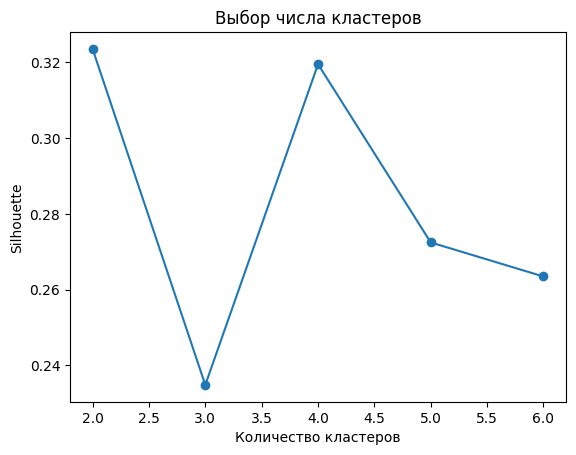

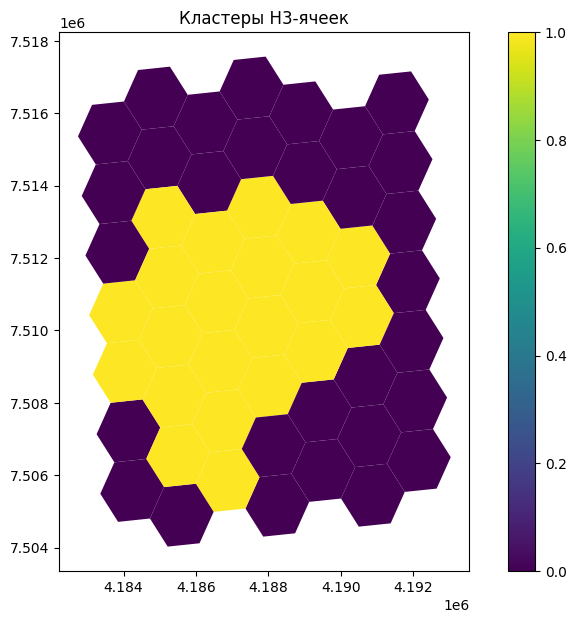

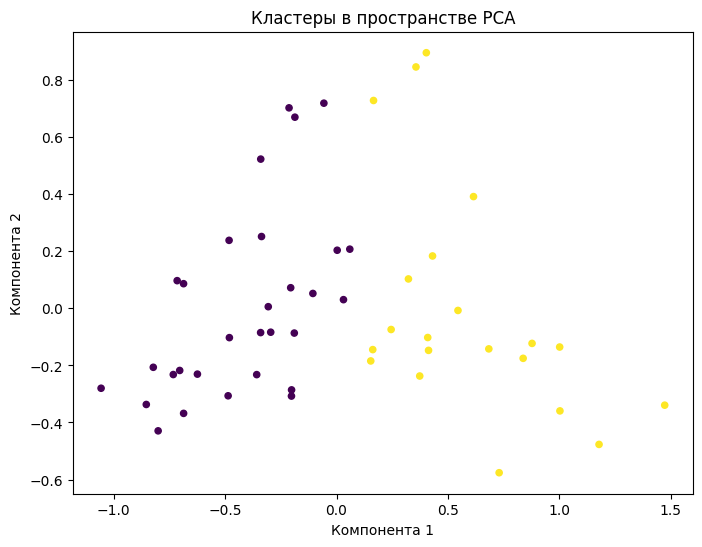


F1 без информации о кластере: 0.9167
F1 с информацией о кластере: 0.9167


In [3]:
# Целевая переменная: наличие ПВЗ Wildberries внутри самой H3-ячейки.
h3_target = h3_gdf[['h3_index', 'geometry']].to_crs('EPSG:4326').copy()

if data['wb'].empty:
    h3_gdf['target'] = 0
else:
    wb_points = data['wb'][['geometry']].to_crs('EPSG:4326')
    joined = gpd.sjoin(
        wb_points,
        h3_target,
        how='left',
        predicate='within'
    )

    target_indexes = joined['index_right'].dropna().astype(int).unique()
    h3_gdf['target'] = 0
    h3_gdf.loc[target_indexes, 'target'] = 1

print('Распределение целевой переменной:')
print(h3_gdf['target'].value_counts())

print('\nДоли классов:')
print(h3_gdf['target'].value_counts(normalize=True).round(3))

model_features = [
    'num_schools_near',
    'num_schools_middle',
    'num_subways_near',
    'num_subways_middle',
    'bike_length_near',
    'bike_length_middle',
    'park_area_near',
    'park_area_middle',
    'restaurant_near',
    'restaurant_middle'
]

X = h3_gdf[model_features]
y = h3_gdf['target']

if y.nunique() < 2:
    print('\nДля обучения модели в выбранной территории получился только один класс.')
    print('Нужно немного расширить bbox и выполнить эту ячейку ещё раз.')
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    }

    results = []
    feature_importance = {}

    for name, model in models.items():
        if name == 'Logistic Regression':
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            importance = pd.Series(
                np.abs(model.coef_[0]),
                index=model_features
            )
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            importance = pd.Series(
                model.feature_importances_,
                index=model_features
            )

        results.append([
            name,
            accuracy_score(y_test, y_pred),
            f1_score(y_test, y_pred, zero_division=0)
        ])

        feature_importance[name] = importance.sort_values(
            ascending=False
        )

        print('\n' + name)
        print(classification_report(
            y_test,
            y_pred,
            zero_division=0
        ))

        print('Важность признаков:')
        display(
            feature_importance[name].to_frame('importance')
        )

    results_df = pd.DataFrame(
        results,
        columns=['Model', 'Accuracy', 'F1']
    )

    display(results_df)

# Кластеризация по пространственным признакам.
cluster_features = model_features

cluster_scaler = MinMaxScaler()
X_cluster = cluster_scaler.fit_transform(
    h3_gdf[cluster_features]
)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

k_values = range(2, 7)
silhouette_values = []

for k in k_values:
    model_k = KMeans(
        n_clusters=k,
        random_state=42
    )
    labels_k = model_k.fit_predict(X_cluster)
    silhouette_values.append(
        silhouette_score(
            X_cluster,
            labels_k
        )
    )

best_k = list(k_values)[
    int(np.argmax(silhouette_values))
]

print('\nЛучшее число кластеров по силуэту:', best_k)

plt.plot(
    list(k_values),
    silhouette_values,
    marker='o'
)
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette')
plt.title('Выбор числа кластеров')
plt.show()

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42
)

h3_gdf['cluster'] = kmeans.fit_predict(
    X_cluster
)

# Визуализация кластеров.
h3_gdf.plot(
    column='cluster',
    figsize=(10, 7),
    legend=True
)
plt.title('Кластеры H3-ячеек')
plt.show()

# PCA.
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=h3_gdf['cluster'],
    s=20
)
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.title('Кластеры в пространстве PCA')
plt.show()

# Проверяем, помогает ли информация о кластере.
if y.nunique() >= 2:
    X_with_cluster = pd.get_dummies(
        h3_gdf[
            model_features + ['cluster']
        ],
        columns=['cluster'],
        dtype=int
    )

    Xc_train, Xc_test, yc_train, yc_test = train_test_split(
        X_with_cluster,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    scaler_c = MinMaxScaler()
    Xc_train_scaled = scaler_c.fit_transform(Xc_train)
    Xc_test_scaled = scaler_c.transform(Xc_test)

    model_cluster = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    model_cluster.fit(
        Xc_train_scaled,
        yc_train
    )

    yc_pred = model_cluster.predict(
        Xc_test_scaled
    )

    f1_without_cluster = results_df.loc[
        results_df['Model'] == 'Logistic Regression',
        'F1'
    ].iloc[0]

    f1_with_cluster = f1_score(
        yc_test,
        yc_pred,
        zero_division=0
    )

    print('\nF1 без информации о кластере:',
          round(f1_without_cluster, 4))
    print('F1 с информацией о кластере:',
          round(f1_with_cluster, 4))


### **Часть 4. Расчет потенциала локаций и финальные рекомендации**



1. **Разработка интегрального показателя потенциала**:
   - Самостоятельно определите веса для факторов привлекательности среды и конкуренции
   - Обоснуйте выбранные веса в контексте вашего бизнеса
   - Рассчитайте итоговый потенциал для всех ячеек сетки
   - Категоризируйте потенциал для упрощения интерпретации результатов

2. **Визуализация результатов**:
   - Создайте интерактивную карту с тепловым слоем потенциала
   - Добавьте маркеры существующих объектов вашего типа бизнеса
   - Выделите топ-10 локаций с наивысшим потенциалом
   - Подготовьте отдельную карту фокуса на лучших локациях

3. **Формирование бизнес-рекомендаций**:
   - Составьте список из 5-7 конкретных локаций для размещения новых объектов
   - Для каждой рекомендуемой локации укажите:
     * Точные координаты
     * Значение потенциала
     * Ключевые характеристики локации
     * Преимущества и возможные риски размещения в данной точке
   - Подготовьте общие рекомендации по стратегии территориального развития для выбранного бизнеса

In [8]:
# Интегральный показатель потенциала.
# Используем веса из теоретического примера:
# школы 0.35, метро 0.30, велодорожки 0.15, парки 0.20.

index_features = [
    'num_schools_middle',
    'num_subways_middle',
    'bike_length_middle',
    'park_area_near'
]

weights = np.array([
    0.35,
    0.30,
    0.15,
    0.20
])

scaler_index = MinMaxScaler()

h3_gdf[index_features] = scaler_index.fit_transform(
    h3_gdf[index_features]
)

h3_gdf['environment_score'] = (
    h3_gdf[index_features].values @ weights
)

# Конкуренция уменьшает потенциал.
competition_scaler = MinMaxScaler()

h3_gdf['competition_score'] = competition_scaler.fit_transform(
    h3_gdf[['wb_middle']]
)

h3_gdf['potential'] = (
    0.8 * h3_gdf['environment_score']
    + 0.2 * (1 - h3_gdf['competition_score'])
)

h3_gdf['potential_category'] = pd.cut(
    h3_gdf['potential'],
    bins=[-0.01, 0.33, 0.66, 1.01],
    labels=['Низкий', 'Средний', 'Высокий']
)

print('Распределение категорий потенциала:')
print(h3_gdf['potential_category'].value_counts())


# Интерактивная карта
h3_gdf_viz = h3_gdf.to_crs('EPSG:4326')

map_potential = leafmap.Map()

map_potential.add_gdf(
    h3_gdf_viz,
    column='potential',
    cmap='OrRd',
    scheme='EqualInterval',
    legend=True,
    layer_name='H3 Сетка'
)

# Существующие ПВЗ
if not data['wb'].empty:
    map_potential.add_gdf(
        data['wb'].to_crs('EPSG:4326'),
        layer_name='Wildberries'
    )

map_potential


# TOP-7 локаций
top7 = h3_gdf.sort_values(
    'potential',
    ascending=False
).head(7).copy()

top7_points = top7.to_crs('EPSG:3857')

top7_points['geometry'] = (
    top7_points.geometry.centroid
)

top7_points = top7_points.to_crs('EPSG:4326')


top7_info = top7_points[
    [
        'h3_index',
        'potential',
        'potential_category',
        'num_schools_middle',
        'num_subways_middle',
        'bike_length_middle',
        'park_area_near',
        'wb_middle'
    ]
].copy()


top7_info['latitude'] = (
    top7_points.geometry.y.round(6)
)

top7_info['longitude'] = (
    top7_points.geometry.x.round(6)
)


def get_advantage(row):
    if row['wb_middle'] == 0:
        return 'Мало конкурентов и хорошая обеспеченность инфраструктурой'
    return 'Хорошая обеспеченность инфраструктурой'


def get_risk(row):
    if row['wb_middle'] > 0:
        return 'Есть конкурирующие ПВЗ поблизости'
    return 'Нужно проверить реальную доступность точки'


top7_info['Преимущество'] = top7_info.apply(
    get_advantage,
    axis=1
)

top7_info['Риск'] = top7_info.apply(
    get_risk,
    axis=1
)


print('\nТОП-7 ЛОКАЦИЙ:')

display(
    top7_info.sort_values(
        'potential',
        ascending=False
    )
)


# Карта TOP-7
map_top7 = leafmap.Map()

map_top7.add_gdf(
    top7_points,
    column='potential',
    cmap='OrRd',
    scheme='EqualInterval',
    legend=True,
    layer_name='TOP-7 локаций'
)

if not data['wb'].empty:
    map_top7.add_gdf(
        data['wb'].to_crs('EPSG:4326'),
        layer_name='Wildberries'
    )

map_top7


print('\nОбщие рекомендации:')

print(
    '1. В первую очередь рассматривать локации из TOP-7.'
)

print(
    '2. Проверять конкуренцию существующих ПВЗ в радиусе 1600 м.'
)

print(
    '3. Перед открытием точки проверить фактическую доступность места.'
)

print(
    '4. Использовать H3-сегментацию для дальнейшего территориального анализа.'
)


Распределение категорий потенциала:
potential_category
Средний    29
Низкий     15
Высокий     7
Name: count, dtype: int64

ТОП-7 ЛОКАЦИЙ:


,h3_index,potential,potential_category,num_schools_middle,num_subways_middle,bike_length_middle,park_area_near,wb_middle,latitude,longitude,Преимущество,Риск
28,8811aa7a87fffff,0.770883,Высокий,0.789474,0.881356,1.000000,0.239409,6.0,55.760034,37.608614,Хорошая обеспеченность инфраструктурой,Есть конкурирующие ПВЗ поблизости
45,8811aa7abdfffff,0.677617,Высокий,0.315789,1.000000,0.740970,0.376747,4.0,55.756574,37.620934,Хорошая обеспеченность инфраструктурой,Есть конкурирующие ПВЗ поблизости
20,8811aa7ab1fffff,0.674473,Высокий,0.842105,0.898305,0.782762,0.182246,14.0,55.761431,37.632342,Хорошая обеспеченность инфраструктурой,Есть конкурирующие ПВЗ поблизости
8,8811aa7a85fffff,0.674452,Высокий,0.789474,0.728814,0.890401,0.135224,9.0,55.755175,37.597212,Хорошая обеспеченность инфраструктурой,Есть конкурирующие ПВЗ поблизости
16,8811aa7ab9fffff,0.673210,Высокий,0.684211,1.000000,0.780734,0.237141,13.0,55.764892,37.620019,Хорошая обеспеченность инфраструктурой,Есть конкурирующие ПВЗ поблизости
5,8811aa7aabfffff,0.665182,Высокий,0.736842,0.508475,0.861853,0.333810,6.0,55.751716,37.609531,Хорошая обеспеченность инфраструктурой,Есть конкурирующие ПВЗ поблизости
29,8811aa7aa1fffff,0.664768,Высокий,0.736842,0.305085,0.793598,1.000000,11.0,55.743398,37.610447,Хорошая обеспеченность инфраструктурой,Есть конкурирующие ПВЗ поблизости



Общие рекомендации:
1. В первую очередь рассматривать локации из TOP-7.
2. Проверять конкуренцию существующих ПВЗ в радиусе 1600 м.
3. Перед открытием точки проверить фактическую доступность места.
4. Использовать H3-сегментацию для дальнейшего территориального анализа.


## **Рекомендации по выполнению**


1. Начните с малой территории для тестирования кода и методологии, затем расширяйте анализ.
2. Используйте инкрементальный подход: сначала реализуйте базовый функционал, затем улучшайте его.
3. Регулярно сохраняйте промежуточные результаты работы.
4. При выборе признаков опирайтесь не только на учебный материал, но и на научные статьи по геоанализу и геомаркетингу.
5. Обращайте внимание на особенности территории и уникальные характеристики выбранного бизнеса.
6. Для оценки результатов старайтесь сопоставить их с реальным расположением успешных объектов аналогичного бизнеса.